# Homework 2

Daniel Ott (33551440), Samuel Šmíd (73123255), Anna Turnerová (70701808)

For the econometric analysis, we use the datasets from the folder 70701808

## Packages

In [ ]:
required_packages <- c("rugarch", "forecast", "FinTS", "ggplot2", "patchwork", "tseries")
  new_packages <- required_packages[!(required_packages %in% installed.packages()[, "Package"])]                                                    
  if (length(new_packages) > 0) install.packages(new_packages)                                                                                      
                                                                                                                                                    
  library(rugarch)   
  library(forecast)                                                                                 
  library(FinTS)                                                                                                           
  library(ggplot2)                                                                                                                      
  library(patchwork) 
  library(tseries)

#### Problem 0: Loading the data

The folder 70701808 should be placed next to this ipynb file for the data loading to work properly

In [2]:
data_dir <- file.path(getwd(), "70701808")                                                                                                        
  if (!dir.exists(data_dir)) {                                                                                                                      
    stop("Data folder '70701808' not found. Place it in the same directory as this notebook.")                                                      
  }                                                                                                                                                                                                                                           

In [3]:
  # We load the three csv files as data frames
  series_A <- read.csv(file.path(data_dir, "series_A.csv"))                                                                                         
  series_B <- read.csv(file.path(data_dir, "series_B.csv"))                                                                                         
  series_C <- read.csv(file.path(data_dir, "series_C.csv"))                                                                                         
                                                                                                                                                    
  # We extract return series as ts objects (we use it later for the ACF, PACF, ARMA, GARCH)
  ret_A <- ts(series_A$ret)                                                                                                                         
  ret_B <- ts(series_B$ret)
  ret_C <- ts(series_C$ret)

We check if there are any inconsistencies in the data

In [4]:
head(series_A)
head(series_B)
head(series_C)

,t,ret,sigma2_true
,<int>,<dbl>,<dbl>
1,1,0.003333625,1e-04
2,2,-0.014436324,1e-04
3,3,-0.014714092,1e-04
4,4,-0.002892057,1e-04
5,5,-0.001163418,1e-04
6,6,-0.017577014,1e-04


,t,ret,sigma2_true
,<int>,<dbl>,<dbl>
1,1,0.001565492,0.0004319325
2,2,-0.013465665,0.0003565024
3,3,0.002000053,0.0003315146
4,4,-0.019286075,0.0002785568
5,5,-0.013757246,0.0003160698
6,6,0.007472438,0.0003432863


,t,ret,sigma2_true
,<int>,<dbl>,<dbl>
1,1,0.0060400710,8.515252e-05
2,2,-0.0097483423,8.130506e-05
3,3,-0.0004913637,8.327098e-05
4,4,-0.0138233888,7.540007e-05
5,5,0.0132157861,1.042986e-04
6,6,0.0017989999,1.008171e-04


In [10]:
head(series_A$sigma2_true)

[1] 1e-04 1e-04 1e-04 1e-04 1e-04 1e-04

Upon initial inspection, it seems that series A has a constant variance of 0,0001. We verify if there is any variation in the variance

In [11]:
all(series_A$sigma2_true == series_A$sigma2_true[1])                                                                                              
  unique(series_A$sigma2_true) 

[1] TRUE

[1] 1e-04

This verifies that the variance of series_A is constant in all rows. We keep this information in mind for later analysis. Meanwhile we check if there are any missing values (gaps in the series)

In [12]:
for (name in c("series_A", "series_B", "series_C")) {
    df <- get(name)                                                                                                                                 
    cat("---", name, "---\n")                                                                                                                       
    cat("Rows:", nrow(df), "\n")                                                                                                                    
    cat("NAs per column:\n")                                                                                                                        
    print(colSums(is.na(df)))                                                                                                                       
    cat("Expected t sequence (1 to", nrow(df), "):", all(df$t == seq_len(nrow(df))), "\n\n")                                                        
  } 

--- series_A ---
Rows: 4000 
NAs per column:
          t         ret sigma2_true 
          0           0           0 
Expected t sequence (1 to 4000 ): TRUE 

--- series_B ---
Rows: 4000 
NAs per column:
          t         ret sigma2_true 
          0           0           0 
Expected t sequence (1 to 4000 ): TRUE 

--- series_C ---
Rows: 4000 
NAs per column:
          t         ret sigma2_true 
          0           0           0 
Expected t sequence (1 to 4000 ): TRUE 



All three series have the same number of rows and there seem to be no missing values in any column. Lastly, we look for type consistency in the columns.

In [13]:
str(series_A)                                                                                                                                     
str(series_B)
str(series_C) 

'data.frame':	4000 obs. of  3 variables:
 $ t          : int  1 2 3 4 5 6 7 8 9 10 ...
 $ ret        : num  0.00333 -0.01444 -0.01471 -0.00289 -0.00116 ...
 $ sigma2_true: num  1e-04 1e-04 1e-04 1e-04 1e-04 1e-04 1e-04 1e-04 1e-04 1e-04 ...
'data.frame':	4000 obs. of  3 variables:
 $ t          : int  1 2 3 4 5 6 7 8 9 10 ...
 $ ret        : num  0.00157 -0.01347 0.002 -0.01929 -0.01376 ...
 $ sigma2_true: num  0.000432 0.000357 0.000332 0.000279 0.000316 ...
'data.frame':	4000 obs. of  3 variables:
 $ t          : int  1 2 3 4 5 6 7 8 9 10 ...
 $ ret        : num  0.00604 -0.009748 -0.000491 -0.013823 0.013216 ...
 $ sigma2_true: num  8.52e-05 8.13e-05 8.33e-05 7.54e-05 1.04e-04 ...


Seems fine as well, we proceed to the analytic part of this assignment

### Problem 1: Preliminary analysis

In [5]:
# --- Helper: build a single return plot ---                                                                                                      
  make_ret_plot <- function(ret_vec, label) {                                                                                                       
    df <- data.frame(t = seq_along(ret_vec), ret = as.numeric(ret_vec))                                                                             
    ggplot(df, aes(x = t, y = ret)) +                                                                                                               
      geom_line(color = "steelblue", linewidth = 0.3) +                                                                                             
      labs(title = paste("Returns –", label), x = "t", y = "Return") +                                                                              
      theme_minimal()                                                                                                                               
  }                                                                                                                                                 
                                                                                                                                                    
  # --- Helper: build a single squared-return plot ---                                                                                              
  make_sq_plot <- function(ret_vec, label) {
    df <- data.frame(t = seq_along(ret_vec), sq = as.numeric(ret_vec)^2)                                                                            
    ggplot(df, aes(x = t, y = sq)) +                                                                                                                
      geom_line(color = "firebrick", linewidth = 0.3) +                                                                                             
      labs(title = paste("Squared Returns –", label), x = "t", y = expression(Return^2)) +                                                          
      theme_minimal()                                                                                                                               
  }                                                                                                                                                 
                                                                                                                                                    
  # --- Build all 6 panels ---                                                                                                                      
  p_retA <- make_ret_plot(ret_A, "Series A")
  p_retB <- make_ret_plot(ret_B, "Series B")                                                                                                        
  p_retC <- make_ret_plot(ret_C, "Series C")                                                                                                        
                                                                                                                                                    
  p_sqA  <- make_sq_plot(ret_A, "Series A")                                                                                                         
  p_sqB  <- make_sq_plot(ret_B, "Series B")                                                                                                         
  p_sqC  <- make_sq_plot(ret_C, "Series C")      

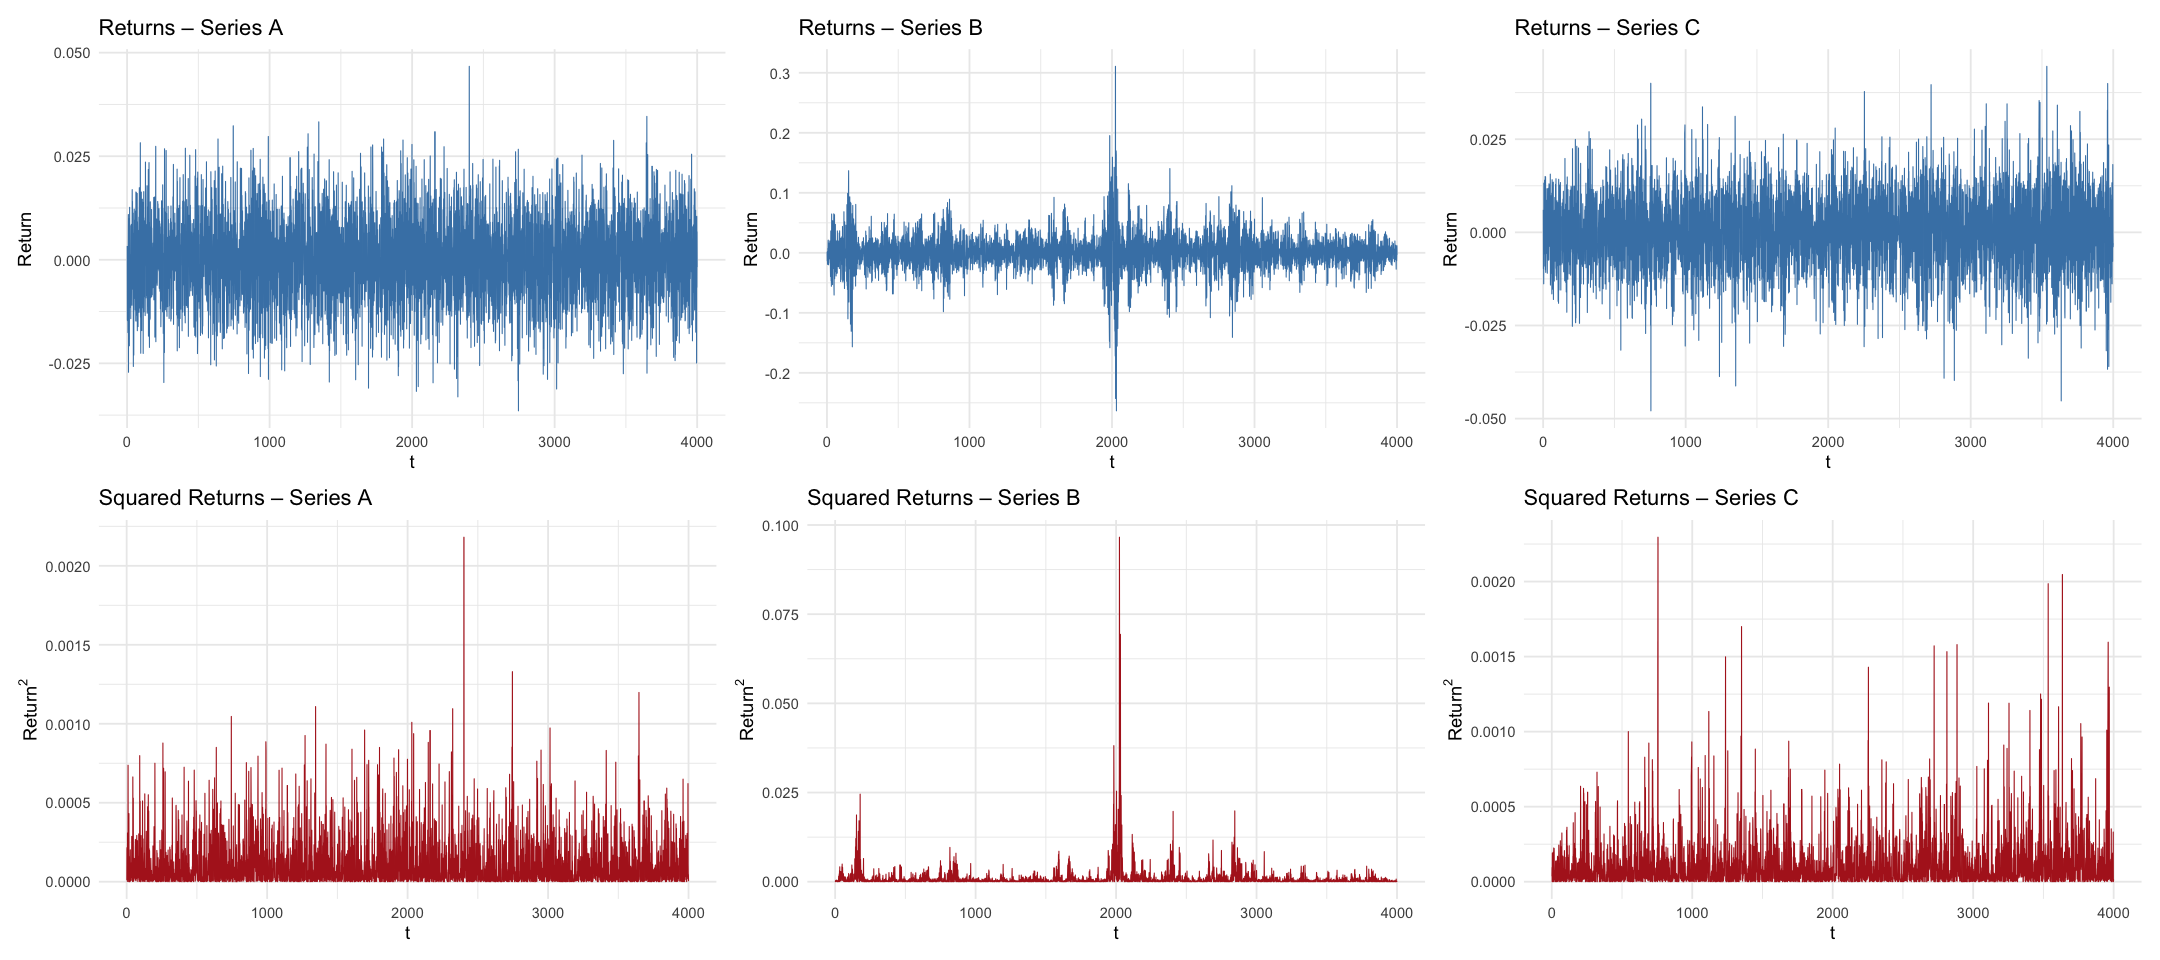

In [7]:
 # --- Combine: returns on top row, squared returns on bottom row ---                                                                              
options(repr.plot.width = 18, repr.plot.height = 8)                                                                                               
  (p_retA | p_retB | p_retC) / (p_sqA | p_sqB | p_sqC)

Based on visual inspection, we form the following hypotheses about volatility clustering of the series:
* least persistent volatilty clustering: Series A - The returns seem to fluctuate uniformly throughout the entire sample and the squared returns show no apparent pattern. The spikes seem to be randomly scattered. This is in line with the fact that the variance of Series A is constant across all time periods. 
* intermediate volatility clustering: Series C
* most persistent volatility clustering: Series B - We suspect the highest volatility clustering for Series B.

### Disclaimer

#### Contributions:

Daniel Ott - Problem 1, Problem 2

Anna Turnerová - Data Preparation, Problem 3, Problem 5

Samuel Šmíd - Problem 4, Problem 6

#### AI usage:

The members of this team used ChatGPT and Google Gemini to help refine the code, especially for the data cleaning and data visualization parts, as well as for polishing of written text.